In [1]:

from google.colab import drive


drive.mount('/content/drive')



Mounted at /content/drive



# A Problemática
Abaixo carregamos uma base de dados com o histórico de preços de carros da tabela FIPE.

Essa base é rica em informações sobre o mercado de carros.
Nesse projeto, iremos nos colocar na posição de um empresário analisando oportunidades de negócios.

Para ter uma sensibilidade sobre o mercado de carros através dessa base, criaremos uma métrica para a depreciação dos carros. Onde na coluna "ano_modelo", o valor 32000 representa um carro zero km

A problemática que abordaremos aqui é a seguinte:

A partir dessa base de dados, e da nossa métrica de depreciação, quais oportunidades podemos enxerga e por quê?

In [2]:
import pandas as pd

Fipe_df = pd.read_csv('/content/drive/MyDrive/Projeto/tabela_fipe_carros.csv')
display(Fipe_df)

print(Fipe_df.shape)

,ano_mes,marca,modelo,codigo_ano,ano_modelo,codigo_tipo_combustivel,combustivel,valor,codigo_fipe,codigo_tipo_veiculo
0,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1999-1,1999,1,Gasolina,28961.0,006009-7,1
1,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1998-1,1998,1,Gasolina,26827.0,006009-7,1
2,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1996-1,1996,1,Gasolina,22494.0,006009-7,1
3,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1995-1,1995,1,Gasolina,21509.0,006009-7,1
4,200101,Alfa Romeo,145 Elegant 2.0 16V,1998-1,1998,1,Gasolina,26764.0,006001-1,1
...,...,...,...,...,...,...,...,...,...,...
5072994,202410,VW - VolksWagen,VOYAGE Trendline 1.0 T.Flex 12V 4p,2017-1,2017,1,Gasolina,43568.0,005457-7,1
5072995,202410,VW - VolksWagen,VOYAGE Trendline 1.6 T.Flex 8V 4p,2018-1,2018,1,Gasolina,45992.0,005380-5,1
5072996,202410,VW - VolksWagen,VOYAGE Trendline 1.6 T.Flex 8V 4p,2017-1,2017,1,Gasolina,43288.0,005380-5,1
5072997,202410,VW - VolksWagen,VOYAGE Trendline 1.6 T.Flex 8V 4p,2016-1,2016,1,Gasolina,41983.0,005380-5,1


(5072999, 10)


Notemos que o data frame possui 5072999 linhas e 10 colunas sobre as quais se dispões as informações dos carros quais podemos destarcar 'ano_mês', 'modelo', 'ano_modelo' e 'valor'.

# A Métrica de Depreciação

Como é dado que carros com ano_modelo== 32000 se refere a carros zero km, usaremos isto como parâmetro para construi nossa métrica.
Comecemos filtrando tais carros

In [3]:
carro_zero = Fipe_df[Fipe_df['ano_modelo'] == 32000].copy() #Cria uma cópia do DF independe do original
carro_zero = carro_zero[['marca', 'modelo', 'ano_mes', 'valor']].rename(columns={'valor': 'preco_zero_km'}) # aqui renomeamos a coluna valor para preco_zero_km

display(carro_zero)


,marca,modelo,ano_mes,preco_zero_km
20,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,200101,66217.0
32,Alfa Romeo,166 3.0 V6 24V,200101,115271.0
146,Audi,A3 1.6 3p,200101,41511.0
149,Audi,A3 1.6 3p Aut.,200101,45646.0
152,Audi,A3 1.6 5p,200101,42210.0
...,...,...,...,...
5072828,VW - VolksWagen,VIRTUS Comfort. 200 TSI 1.0 Flex 12V Aut,202410,127951.0
5072837,VW - VolksWagen,VIRTUS Exclusive 250TSI 1.4 Flex 16V Aut,202410,149124.0
5072844,VW - VolksWagen,VIRTUS Highline 200 TSI 1.0 Flex 12V Aut,202410,138236.0
5072857,VW - VolksWagen,VIRTUS TSI 1.0 Flex 12V 4p Aut.,202410,116570.0


Agora, tendo os carros zero km filtrados bem como seus respectivos preços. Adicionaremos isso ao Data frame principal

In [4]:
Fipe_copia_df = Fipe_df.copy() #criamos uma copia de segurança do DF original

Fipe_df= pd.merge(Fipe_df,carro_zero,  on=['marca', 'modelo', 'ano_mes'],how='left') #E aqui adicionamos a esses carros zero km ao Df principal

display(Fipe_df. head(33))

,ano_mes,marca,modelo,codigo_ano,ano_modelo,codigo_tipo_combustivel,combustivel,valor,codigo_fipe,codigo_tipo_veiculo,preco_zero_km
0,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1999-1,1999,1,Gasolina,28961.0,006009-7,1,NaN
1,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1998-1,1998,1,Gasolina,26827.0,006009-7,1,NaN
2,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1996-1,1996,1,Gasolina,22494.0,006009-7,1,NaN
3,200101,Alfa Romeo,145 Elegant 1.7/1.8 16V,1995-1,1995,1,Gasolina,21509.0,006009-7,1,NaN
4,200101,Alfa Romeo,145 Elegant 2.0 16V,1998-1,1998,1,Gasolina,26764.0,006001-1,1,NaN
5,200101,Alfa Romeo,145 Elegant 2.0 16V,1997-1,1997,1,Gasolina,25205.0,006001-1,1,NaN
6,200101,Alfa Romeo,145 Elegant 2.0 16V,1996-1,1996,1,Gasolina,22664.0,006001-1,1,NaN
7,200101,Alfa Romeo,145 Elegant 2.0 16V,1995-1,1995,1,Gasolina,20369.0,006001-1,1,NaN
8,200101,Alfa Romeo,145 Quadrifoglio 2.0,1999-1,1999,1,Gasolina,31437.0,006002-0,1,NaN
9,200101,Alfa Romeo,145 Quadrifoglio 2.0,1998-1,1998,1,Gasolina,27851.0,006002-0,1,NaN


É possível notar que no DF acima os carros cuja os modelos possuem um modelo zero km tem a coluna 'preco_zero_km' o valor do preço do carro zero. Já os modelos que não possuem um modelo zero km correspondente estão 'NaN' nesta mesma coluna. Agora iremos filtrar esses carros pois não é possível obter a depreciação destes.

In [5]:
Fipe_df.dropna(subset=['preco_zero_km'], inplace=True)
display(Fipe_df.head(50))

,ano_mes,marca,modelo,codigo_ano,ano_modelo,codigo_tipo_combustivel,combustivel,valor,codigo_fipe,codigo_tipo_veiculo,preco_zero_km
20,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,32000-1,32000,1,Gasolina,66217.0,006010-0,1,66217.0
21,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,2000-1,2000,1,Gasolina,59000.0,006010-0,1,66217.0
22,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,1999-1,1999,1,Gasolina,52749.0,006010-0,1,66217.0
23,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,1998-1,1998,1,Gasolina,47138.0,006010-0,1,66217.0
32,200101,Alfa Romeo,166 3.0 V6 24V,32000-1,32000,1,Gasolina,115271.0,006011-9,1,115271.0
33,200101,Alfa Romeo,166 3.0 V6 24V,2000-1,2000,1,Gasolina,109536.0,006011-9,1,115271.0
34,200101,Alfa Romeo,166 3.0 V6 24V,1999-1,1999,1,Gasolina,95812.0,006011-9,1,115271.0
146,200101,Audi,A3 1.6 3p,32000-1,32000,1,Gasolina,41511.0,008032-2,1,41511.0
147,200101,Audi,A3 1.6 3p,2000-1,2000,1,Gasolina,38009.0,008032-2,1,41511.0
148,200101,Audi,A3 1.6 3p,1999-1,1999,1,Gasolina,34820.0,008032-2,1,41511.0


Agora finalmente podemos obter a depreciação através da seguinte expressão

(preco_zero_km - valor)/preco_zero_km * 100

Dessa forma, segue abaixo o DF com a depreciação percentual

In [6]:
Fipe_df ['Depreciação Percentual'] = ((Fipe_df['preco_zero_km'] - Fipe_df['valor'])/Fipe_df['preco_zero_km'])*100
display(Fipe_df)

,ano_mes,marca,modelo,codigo_ano,ano_modelo,codigo_tipo_combustivel,combustivel,valor,codigo_fipe,codigo_tipo_veiculo,preco_zero_km,Depreciação Percentual
20,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,32000-1,32000,1,Gasolina,66217.0,006010-0,1,66217.0,0.000000
21,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,2000-1,2000,1,Gasolina,59000.0,006010-0,1,66217.0,10.899014
22,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,1999-1,1999,1,Gasolina,52749.0,006010-0,1,66217.0,20.339188
23,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,1998-1,1998,1,Gasolina,47138.0,006010-0,1,66217.0,28.812843
32,200101,Alfa Romeo,166 3.0 V6 24V,32000-1,32000,1,Gasolina,115271.0,006011-9,1,115271.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
5093568,202410,VW - VolksWagen,VIRTUS TSI 1.0 Flex 12V 4p Aut.,2023-1,2023,1,Gasolina,99246.0,005543-3,1,116570.0,14.861457
5093569,202410,VW - VolksWagen,VIRTUS TSI 1.0 Flex 12V 4p Mec.,32000-1,32000,1,Gasolina,111653.0,005542-5,1,111653.0,0.000000
5093570,202410,VW - VolksWagen,VIRTUS TSI 1.0 Flex 12V 4p Mec.,2025-1,2025,1,Gasolina,105260.0,005542-5,1,111653.0,5.725775
5093571,202410,VW - VolksWagen,VIRTUS TSI 1.0 Flex 12V 4p Mec.,2024-1,2024,1,Gasolina,95672.0,005542-5,1,111653.0,14.313095


# Analise dos Resultados

Para analisarmos os resultados será de grande ajudar obtermos a idades dos carros. Para tanto, tomesmo o que segue

In [7]:
Fipe_df['ano_referencia'] = Fipe_df['ano_mes'].astype(str).str[:4].astype(int) # Aqui estamos pegando a coluna ano_mes e tirando o mês, deixando apenas o ano
Fipe_df['idade_carro'] = Fipe_df.apply(lambda row: 0 if row['ano_modelo'] == 32000
                                       else (row['ano_referencia'] - row['ano_modelo']),axis=1) # Aqui estamos tomando a idade do carro como 0 caso o carro seja zero km e a diferença entre ano_referencia e ano_modelo caso contrário.
Fipe_df['idade_carro'] = Fipe_df['idade_carro'].apply(lambda x: max(0, x)) #aqui estamos garantindo que a idade do carro será positiva
Fipe_df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)
Fipe_df.dropna(subset=['Depreciação Percentual'], inplace=True)#E aqui estamos garantindo que não temos infinitos que possam surgir por divisão por zero
display(Fipe_df.head(40))

,ano_mes,marca,modelo,codigo_ano,ano_modelo,codigo_tipo_combustivel,combustivel,valor,codigo_fipe,codigo_tipo_veiculo,preco_zero_km,Depreciação Percentual,ano_referencia,idade_carro
20,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,32000-1,32000,1,Gasolina,66217.0,006010-0,1,66217.0,0.000000,2001,0
21,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,2000-1,2000,1,Gasolina,59000.0,006010-0,1,66217.0,10.899014,2001,1
22,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,1999-1,1999,1,Gasolina,52749.0,006010-0,1,66217.0,20.339188,2001,2
23,200101,Alfa Romeo,156 TS/Sport/Elegant 2.0 16V,1998-1,1998,1,Gasolina,47138.0,006010-0,1,66217.0,28.812843,2001,3
32,200101,Alfa Romeo,166 3.0 V6 24V,32000-1,32000,1,Gasolina,115271.0,006011-9,1,115271.0,0.000000,2001,0
33,200101,Alfa Romeo,166 3.0 V6 24V,2000-1,2000,1,Gasolina,109536.0,006011-9,1,115271.0,4.975232,2001,1
34,200101,Alfa Romeo,166 3.0 V6 24V,1999-1,1999,1,Gasolina,95812.0,006011-9,1,115271.0,16.881089,2001,2
146,200101,Audi,A3 1.6 3p,32000-1,32000,1,Gasolina,41511.0,008032-2,1,41511.0,0.000000,2001,0
147,200101,Audi,A3 1.6 3p,2000-1,2000,1,Gasolina,38009.0,008032-2,1,41511.0,8.436318,2001,1
148,200101,Audi,A3 1.6 3p,1999-1,1999,1,Gasolina,34820.0,008032-2,1,41511.0,16.118619,2001,2


Agora para de fato comerçarmos a analise tomemos a depreciação média por ideada, a qual é dada por

In [8]:
depreciacao_por_idade = Fipe_df.groupby('idade_carro')['Depreciação Percentual'].mean().reset_index()
display(depreciacao_por_idade)

,idade_carro,Depreciação Percentual
0,0,5.307430
1,1,16.905667
2,2,24.314198
3,3,32.012068
4,4,38.972882
5,5,45.025241
6,6,50.430890
7,7,55.232412
8,8,59.451168
9,9,63.156988


Com isto utilizemos as bibliotecas matplotlib e seaborn para plotarmos um gráfico de disperção média por idade do carro

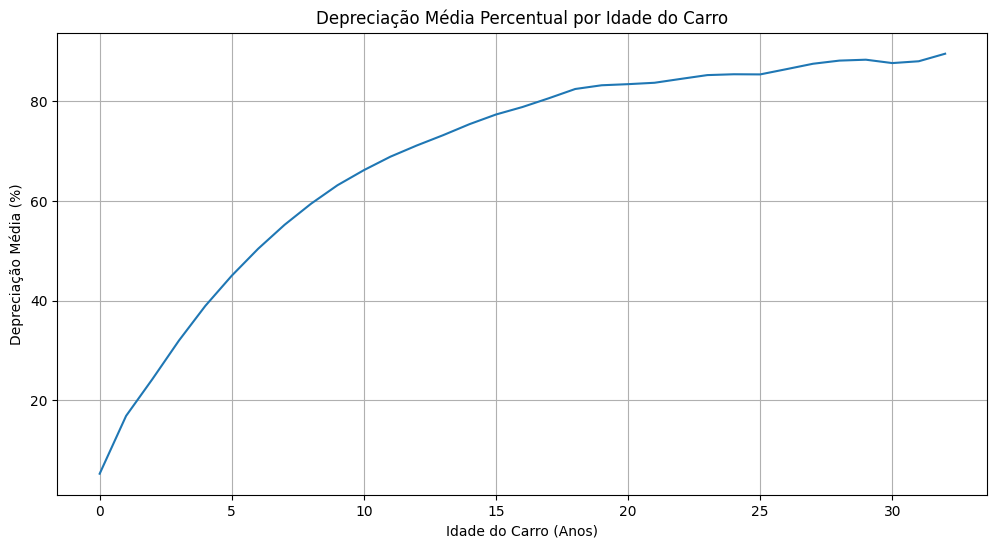

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='idade_carro', y='Depreciação Percentual', data=depreciacao_por_idade)
plt.title('Depreciação Média Percentual por Idade do Carro')
plt.xlabel('Idade do Carro (Anos)')
plt.ylabel('Depreciação Média (%)')
plt.grid(True)
plt.show()

O gáfico nos mostra que a relação entre Depreciação média e a idade do carro é aproximadamente um crecimento logaritimico.
Para obtermos uma intepretaçao melhor dos dados, tomesmo os 10 modelos com menor depreciação e os 10 modelos com maior depreciação

In [10]:
carros_usados = Fipe_df[Fipe_df['idade_carro'] > 0] # estamos tomando todos os carros com idade superior a 0 (ou seja os que não são zero km)


depreciacao_media_modelo = carros_usados.groupby(['marca', 'modelo'])['Depreciação Percentual'].mean().reset_index() # agrupamos por marca e modelo para pegar a depreciação média

print("\nTop 10 Modelos com Menor Depreciação (mantêm mais valor):")
display(depreciacao_media_modelo.sort_values(by='Depreciação Percentual', ascending=True).head(10)) #Aqui estamos tomando os 10 modelos com menor depreciação

print("\nTop 10 Modelos com Maior Depreciação (perdem mais valor):")
display(depreciacao_media_modelo.sort_values(by='Depreciação Percentual', ascending=False).head(10)) #Aqui estamos tomando os 10 modelos com mairo depreciação


Top 10 Modelos com Menor Depreciação (mantêm mais valor):


,marca,modelo,Depreciação Percentual
5426,VW - VolksWagen,T-Cross Sense 1.0 TSI Flex 5p Aut.(PCD),2.685780
4990,Toyota,YARIS S 1.5 Flex 16V 5p Aut.,3.526870
2963,Land Rover,Range Rover Autobio. 2.0 Si4 (Hibrido),3.596285
2909,Land Rover,Range R. VEL. R-Dyn.SE 3.0 PH6 4x4 Aut.,3.604831
3151,Mclaren,765LT Coupe 4.0 Bi-Turbo V8,3.620720
3152,Mclaren,765LT Spider 4.0 Bi-Turbo V8,3.644363
5033,Troller,T-4 TX4 Connect 4x4 3.2 Cap.Ríg.Die.Mec.,3.648479
3923,Nissan,VERSA V-DRIVE Esp.Ed. 1.6 16v Flex Aut.,3.669488
4655,Rolls-Royce,Cullinan 6.7 V12 Aut.,3.693192
3729,Mitsubishi,Pajero Full Legend Ed.3.2 T.I. Die. Aut.,3.723396



Top 10 Modelos com Maior Depreciação (perdem mais valor):


,marca,modelo,Depreciação Percentual
421,BMW,750i,91.957092
344,BMW,325i,88.358933
2300,Hyundai,Elantra GLS 1.8 16V,86.119518
5301,VW - VolksWagen,Passat 2.0,74.241911
2180,Honda,Accord Sedan LX 2.2/2.4 16V,74.153364
4833,Suzuki,Vitara JLX 2.0 V6 4x4,73.701750
382,BMW,525i/iA,73.250971
2176,Honda,Accord Sedan EX 2.4/2.3/ 2.2 16V,71.749615
423,BMW,750iA,71.172431
2668,Kia Motors,Carnival EX 3.5 V6 24V 276/272cv Aut.,69.720253


Com base na analise que fizemos acima podemos afirmar que os modelos de carros que são mais propícios a venda, pensando na maior margem de lucro, com base na menor depreciação (2.69%), é o T-Cross Sense 1.0 TSI Flex 5p Aut.(PCD) da VolksWagen. Em contra partida, o melhor modelo para se comprar, visando o menor gasto, com base na maior depreciação (91.96%), é o 750i da BMW.

Para além disso, ainda podemos ainda analisar as melhores oportunidades de negócio observando os modelos premium (melhor status) as quais possuem uma depreciação intermediaria, isto é não é tão caro para se comprar e nem tão barato para se vender. Para isto, vamo filtrar carros com que tenham 2 anos e cuja o valor do preço do zero km seja maior que 150000. Tal analise está disposta a seguir

In [11]:

oportunidades = carros_usados[ (carros_usados['idade_carro'] == 2) & (carros_usados['preco_zero_km'] > 150000)].sort_values('Depreciação Percentual', ascending=False).head(5)

display(oportunidades[['marca','modelo','valor','Depreciação Percentual']])

,marca,modelo,valor,Depreciação Percentual
93098,Mercedes-Benz,CL-600 6.0/ 5.5,196725.0,66.322689
84429,Mercedes-Benz,CL-600 6.0/ 5.5,199458.0,65.198411
314856,Audi,A8 4.2 Quattro Tiptronic,176928.0,63.874182
275527,Audi,A8 4.2 Quattro Tiptronic,177103.0,63.775284
425405,Subaru,Outback 2.5 4x4 Aut.,80179.0,63.595045


Dessa forma, os modelos destacado no DF acima são as melhores oportunidades de negócio. Pois podemos comprá-los por mais da metade do preço e revende-los em um ou dois anos, perdendo mínimamente o quanto investimos na compra.